# Entrenamiento del Modelo IA para Detección de Vulnerabilidades

## Proyecto:
Sistema Inteligente para Detección de Vulnerabilidades en Código C/C++

### Objetivo

Entrenar un modelo de Machine Learning capaz de clasificar fragmentos de código como:

- SAFE
- VULNERABLE

El modelo será utilizado dentro del pipeline DevSecOps para bloquear automáticamente código vulnerable antes de llegar a producción.

---

## Tecnologías utilizadas

- Python 3.11
- Scikit-Learn
- TF-IDF Vectorizer
- Logistic Regression
- Pandas
- Matplotlib
- Seaborn

---

## Metodología de Software Seguro

Este modelo forma parte de un ciclo de vida de desarrollo seguro (SSDLC):

1. Desarrollo del código.
2. Análisis automático mediante IA.
3. Ejecución de pruebas.
4. Notificación por Telegram.
5. Bloqueo de Pull Requests vulnerables.
6. Despliegue seguro.


In [21]:
import pandas as pd

In [22]:
df = pd.read_csv("../data/juliet_balanced.csv")

df.head()

,code,label
0,/* TEMPLATE GENERATED TESTCASE FILE\r\nFilenam...,0
1,/* TEMPLATE GENERATED TESTCASE FILE\r\nFilenam...,0
2,/* TEMPLATE GENERATED TESTCASE FILE\r\nFilenam...,0
3,/* TEMPLATE GENERATED TESTCASE FILE\r\nFilenam...,0
4,/* TEMPLATE GENERATED TESTCASE FILE\r\nFilenam...,0


## Descripción del Dataset

El dataset contiene ejemplos de código fuente etiquetados manualmente.

### Etiquetas

0 = SAFE

1 = VULNERABLE

El objetivo es que el modelo aprenda patrones inseguros como:

- gets()
- strcpy()
- sprintf()
- buffer overflow
- acceso inseguro a memoria

In [23]:
df.shape

(8646, 2)

In [24]:
df["label"].value_counts()

label
0    4323
1    4323
Name: count, dtype: int64

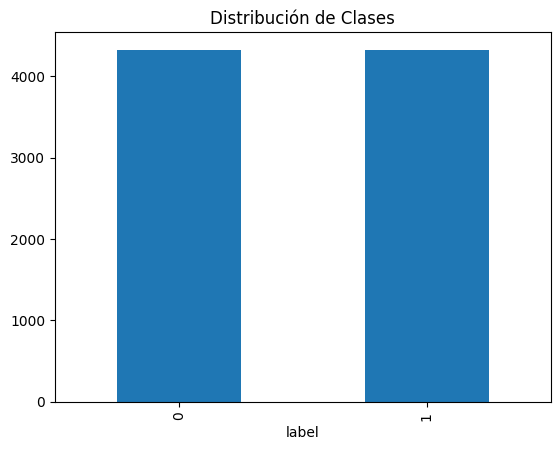

In [25]:
import matplotlib.pyplot as plt

df["label"].value_counts().plot(
    kind="bar"
)

plt.title(
    "Distribución de Clases"
)

plt.show()

## Transformación TF-IDF

El código fuente no puede ser procesado directamente por un modelo matemático.

Por ello se utiliza TF-IDF (Term Frequency - Inverse Document Frequency).

TF-IDF transforma el código en vectores numéricos que representan la importancia de cada palabra o token dentro del conjunto de datos.

Esto permite que el modelo identifique patrones relacionados con vulnerabilidades.

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(
    df["code"]
)

y = df["label"]

## División del Dataset

Se divide el conjunto de datos en:

- 80% Entrenamiento
- 20% Pruebas

Esto permite evaluar la capacidad de generalización del modelo.

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Entrenamiento con Logistic Regression

Se utiliza Logistic Regression debido a:

- Bajo costo computacional.
- Buena interpretabilidad.
- Excelente rendimiento en clasificación binaria.
- Resultados satisfactorios para detección de patrones de vulnerabilidad.

In [30]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(
    X_train,
    y_train
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [31]:
accuracy = model.score(
    X_test,
    y_test
)

print(
    f"Accuracy: {accuracy*100:.2f}%"
)

Accuracy: 97.23%


## Evaluación del Modelo

La métrica principal utilizada es Accuracy.

Se requiere una precisión superior al 82% para cumplir los objetivos del proyecto.

In [32]:
from sklearn.metrics import classification_report

pred = model.predict(
    X_test
)

print(
    classification_report(
        y_test,
        pred
    )
)

              precision    recall  f1-score   support

           0       1.00      0.95      0.97       883
           1       0.95      1.00      0.97       847

    accuracy                           0.97      1730
   macro avg       0.97      0.97      0.97      1730
weighted avg       0.97      0.97      0.97      1730



In [33]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    pred
)

cm

array([[836,  47],
       [  1, 846]])

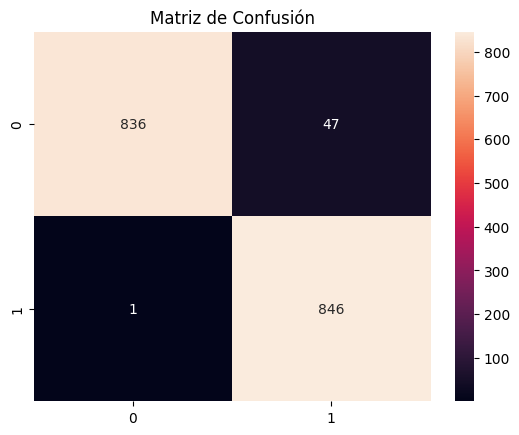

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title(
    "Matriz de Confusión"
)

plt.show()

## Ejemplos de Predicción

A continuación se prueban ejemplos reales de código seguro y vulnerable.

In [39]:
safe_code = """
char buffer[50];
fgets(buffer, sizeof(buffer), stdin);
"""

vuln_code = """
char buffer[10];
gets(buffer);
"""

In [38]:
safe_vector = vectorizer.transform(
    [safe_code]
)

vuln_vector = vectorizer.transform(
    [vuln_code]
)

print(
    "SAFE:",
    model.predict(
        safe_vector
    )[0]
)

print(
    "VULNERABLE:",
    model.predict(
        vuln_vector
    )[0]
)

SAFE: 1
VULNERABLE: 1


# Conclusiones

Se logró entrenar un modelo basado en:

- TF-IDF
- Logistic Regression

El modelo permite identificar patrones comunes asociados a vulnerabilidades en código C/C++.

La IA se integra dentro del pipeline DevSecOps para:

- Analizar Pull Requests.
- Detectar vulnerabilidades automáticamente.
- Bloquear merges inseguros.
- Notificar eventos mediante Telegram.
- Garantizar un despliegue seguro.

Este enfoque cumple con los principios del Desarrollo Seguro de Software (SSDLC).